In [10]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from morl_behavior_objective.analysis.metrics_clean import compute_zadu_metrics
from morl_behavior_objective.utils import get_pareto_front
from morl_behavior_objective.utils import load_transformer_embeddings
from morl_behavior_objective.utils import render_policy

# Set matplotlib parameters
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["pdf.fonttype"] = 42  # use true-type
mpl.rcParams["ps.fonttype"] = 42  # use true-type
mpl.rcParams["font.size"] = 18
mpl.rcParams["lines.linewidth"] = 2.2
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath,amssymb,underscore}"
mpl.rcParams["text.usetex"] = True
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["legend.fontsize"] = 16

colors = [
    "#5CB5FF",
    "#D55E00",
    "#009E73",
    "#e6194b",
]

## Load all the data

### Load all environments

In [2]:
seed = 4

# Configuration for environments
environments = {
    "cheetah": {
        "trajectory_dir": "../../trajectories/morld/mo-halfcheetah-v5/seed0",
        "embedding_path": f"../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_be_MHC_e100_seed{seed}.json",
    },
    "highway": {
        "trajectory_dir": "../../trajectories/morld/mo-highway-fast-v0/seed0",
        "embedding_path": f"../../trajectories/morld/mo-highway-fast-v0/embeddings/mean_be_MHW_e100_seed{seed}.json",
    },
    "hopper_2d": {
        "trajectory_dir": "../../trajectories/morld/mo-hopper-2obj-v5/seed0",
        "embedding_path": f"../../trajectories/morld/mo-hopper-2obj-v5/embeddings/mean_be_MHo2_e100_seed{seed}.json",
    },
    "hopper_3d": {
        "trajectory_dir": "../../trajectories/morld/mo-hopper-v5/seed0",
        "embedding_path": f"../../trajectories/morld/mo-hopper-v5/embeddings/mean_be_MHo_e100_seed{seed}.json",
    },
}

# Load returns (Pareto fronts)
returns_cheetah = get_pareto_front(environments["cheetah"]["trajectory_dir"])

returns_highway = get_pareto_front(environments["highway"]["trajectory_dir"])

returns_hopper_2d = get_pareto_front(environments["hopper_2d"]["trajectory_dir"])

returns_hopper_3d = get_pareto_front(environments["hopper_3d"]["trajectory_dir"])

# Load transformer embeddings
all_t_emb_cheetah, _ = load_transformer_embeddings(environments["cheetah"]["embedding_path"])
all_t_emb_high, _ = load_transformer_embeddings(environments["highway"]["embedding_path"])
all_t_emb_hopper_2d, _ = load_transformer_embeddings(environments["hopper_2d"]["embedding_path"])
all_t_emb_hopper_3d, _ = load_transformer_embeddings(environments["hopper_3d"]["embedding_path"])

print("Data loaded successfully:")
print(f" Cheetah: returns shape: {returns_cheetah.shape}, embeddings shape: {all_t_emb_cheetah.shape}")
print(f" Highway: returns shape: {returns_highway.shape}, embeddings shape: {all_t_emb_high.shape}")
print(f" Hopper 2D: returns shape: {returns_hopper_2d.shape}, embeddings shape: {all_t_emb_hopper_2d.shape}")
print(f" Hopper 3D: returns shape: {returns_hopper_3d.shape}, embeddings shape: {all_t_emb_hopper_3d.shape}")

Data loaded successfully:
 Cheetah: returns shape: (80, 2), embeddings shape: (80, 3)
 Highway: returns shape: (41, 3), embeddings shape: (41, 3)
 Hopper 2D: returns shape: (35, 2), embeddings shape: (35, 3)
 Hopper 3D: returns shape: (160, 3), embeddings shape: (160, 3)


## Trustworthiness and Continuity

In [3]:
print("\n--- RAW METRICS ---")
print("Returns vs highway embedding:", compute_zadu_metrics(returns_highway, all_t_emb_high))
print(" Returns vs cheetah embedding:", compute_zadu_metrics(returns_cheetah, all_t_emb_cheetah))


--- RAW METRICS ---
Returns vs highway embedding: [{'trustworthiness': 0.7391869918699188, 'continuity': 0.7941463414634147}, {'mrre_false': 0.7343943778420835, 'mrre_missing': 0.7854485324514263}]
 Returns vs cheetah embedding: [{'trustworthiness': 0.9532679738562091, 'continuity': 0.9454248366013072}, {'mrre_false': 0.9488297872340425, 'mrre_missing': 0.9375531914893618}]


In [4]:
# This computes average and std trustworthiness and continuity over all seeds
print("=== ZADU METRICS COMPUTATION ===")

trustworthiness_cheetah_pf_t = []
trustworthiness_hopper_pf_t = []
trustworthiness_cheetah_pf_mlp = []
trustworthiness_highway_pf_t = []
trustworthiness_hopper2d_pf_t = []
trustworthiness_hopper3d_pf_t = []

continuity_cheetah_pf_t = []
continuity_hopper_pf_t = []
continuity_highway_pf_t = []
continuity_hopper2d_pf_t = []
continuity_hopper3d_pf_t = []
continuity_cheetah_pf_mlp = []


for seed in range(5):
    # Configuration for datasets
    environments = {
        "cheetah": {
            "trajectory_dir": "../../trajectories/morld/mo-halfcheetah-v5/seed0",
            "embedding_path": f"../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_be_MHC_e100_seed{seed}.json",
            "mlp_path": f"../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_mlp_MHC_e100_seed{seed}_mlp.json",
        },
        "highway": {
            "trajectory_dir": "../../trajectories/morld/mo-highway-fast-v0/seed0",
            "embedding_path": f"../../trajectories/morld/mo-highway-fast-v0/embeddings/mean_be_MHW_e100_seed{seed}.json",
        },
        "hopper_2d": {
            "trajectory_dir": f"../../trajectories/morld/mo-hopper-2obj-v5/seed0",
            "embedding_path": f"../../trajectories/morld/mo-hopper-2obj-v5/embeddings/mean_be_MHo2_e100_seed{seed}.json",
        },
        "hopper_3d": {
            "trajectory_dir": f"../../trajectories/morld/mo-hopper-v5/seed0",
            "embedding_path": f"../../trajectories/morld/mo-hopper-v5/embeddings/mean_be_MHo_e100_seed{seed}.json",
        },
    }


    cheetah_emb_seed, _ = load_transformer_embeddings(environments["cheetah"]["embedding_path"])
    cheetah_mlp_emb_seed = load_transformer_embeddings(environments["cheetah"]["mlp_path"])[0]
    highway_emb_seed, _ = load_transformer_embeddings(environments["highway"]["embedding_path"])
    hopper_2d_emb_seed, _ = load_transformer_embeddings(environments["hopper_2d"]["embedding_path"])
    hopper_3d_emb_seed, _ = load_transformer_embeddings(environments["hopper_3d"]["embedding_path"])

    returns_cheetah_seed = get_pareto_front(environments["cheetah"]["trajectory_dir"])
    returns_highway_seed = get_pareto_front(environments["highway"]["trajectory_dir"])
    returns_hopper_2d_seed = get_pareto_front(environments["hopper_2d"]["trajectory_dir"])
    returns_hopper_3d_seed = get_pareto_front(environments["hopper_3d"]["trajectory_dir"])

    cheetah_pf_t = compute_zadu_metrics(returns_cheetah_seed, cheetah_emb_seed)
    highway_pf_t = compute_zadu_metrics(returns_highway_seed, highway_emb_seed)
    hopper_2d_pf_t = compute_zadu_metrics(returns_hopper_2d_seed, hopper_2d_emb_seed)
    hopper_3d_pf_t = compute_zadu_metrics(returns_hopper_3d_seed, hopper_3d_emb_seed)

    trustworthiness_cheetah_pf_t.append(cheetah_pf_t[0]["trustworthiness"])
    continuity_cheetah_pf_t.append(cheetah_pf_t[0]["continuity"])
    trustworthiness_cheetah_pf_mlp.append(cheetah_pf_mlp[0]["trustworthiness"])
    continuity_cheetah_pf_mlp.append(cheetah_pf_mlp[0]["continuity"])
    trustworthiness_highway_pf_t.append(highway_pf_t[0]["trustworthiness"])
    continuity_highway_pf_t.append(highway_pf_t[0]["continuity"])
    trustworthiness_hopper2d_pf_t.append(hopper_2d_pf_t[0]["trustworthiness"])
    continuity_hopper2d_pf_t.append(hopper_2d_pf_t[0]["continuity"])
    trustworthiness_hopper3d_pf_t.append(hopper_3d_pf_t[0]["trustworthiness"])
    continuity_hopper3d_pf_t.append(hopper_3d_pf_t[0]["continuity"])



print("trustworthiness_cheetah_pf_t", np.mean(trustworthiness_cheetah_pf_t), "\\pm", np.std(trustworthiness_cheetah_pf_t))

print("continuity_cheetah_pf_t", np.mean(continuity_cheetah_pf_t), "\\pm", np.std(continuity_cheetah_pf_t))

print("trustworthiness_cheetah_pf_mlp", np.mean(trustworthiness_cheetah_pf_mlp), "\\pm", np.std(trustworthiness_cheetah_pf_mlp))

print("continuity_cheetah_pf_mlp", np.mean(continuity_cheetah_pf_mlp), "\\pm", np.std(continuity_cheetah_pf_mlp))


print("trustworthiness_highway_pf_t", np.mean(trustworthiness_highway_pf_t), "\\pm", np.std(trustworthiness_highway_pf_t))

print("continuity_highway_pf_t", np.mean(continuity_highway_pf_t), "\\pm", np.std(continuity_highway_pf_t))

print("trustworthiness_hopper_2d_pf_t", np.mean(trustworthiness_hopper2d_pf_t), "\\pm", np.std(trustworthiness_hopper2d_pf_t))

print("continuity_hopper_2d_pf_t", np.mean(continuity_hopper2d_pf_t), "\\pm", np.std(continuity_hopper2d_pf_t))

print("trustworthiness_hopper_3d_pf_t", np.mean(trustworthiness_hopper3d_pf_t), "\\pm", np.std(trustworthiness_hopper3d_pf_t))

print("continuity_hopper_3d_pf_t", np.mean(continuity_hopper3d_pf_t), "\\pm", np.std(continuity_hopper3d_pf_t))



=== ZADU METRICS COMPUTATION ===


NameError: name 'cheetah_pf_mlp' is not defined

## Trustworthiness and Continuity over k

In [2]:
import numpy as np

def _pairwise_sq_dists(X: np.ndarray) -> np.ndarray:
    """
    Compute full pairwise squared Euclidean distance matrix.
    Shape: (n, n)
    """
    X = np.asarray(X, dtype=float)
    G = X @ X.T
    sq = np.sum(X * X, axis=1, keepdims=True)
    D = sq - 2.0 * G + sq.T
    # numerical stability
    np.maximum(D, 0.0, out=D)
    return D

def _knn_order_from_dists(D: np.ndarray) -> np.ndarray:
    """
    For each i, returns an array of indices sorted by increasing distance,
    excluding i itself. Shape: (n, n-1)
    """
    n = D.shape[0]
    D = D.copy()
    np.fill_diagonal(D, np.inf)
    order = np.argsort(D, axis=1)
    return order[:, : n - 1]

def _rank_matrix_from_order(order: np.ndarray) -> np.ndarray:
    """
    Given order[i, :] listing neighbors (closest to farthest),
    return rank[i, j] = 1..n-1 for neighbor j (excluding i).
    For i==j, rank is 0.
    Shape: (n, n)
    """
    n = order.shape[0]
    rank = np.zeros((n, n), dtype=int)
    # ranks are 1..n-1
    ranks = np.arange(1, n, dtype=int)
    for i in range(n):
        rank[i, order[i]] = ranks
    return rank

def trustworthiness_continuity_over_k(
    raw_data,
    embeddings,
    k_min: int = 1,
    k_max: int | None = None,
) -> dict:
    """
    Compute trustworthiness and continuity for each k from scratch.

    Parameters
    ----------
    raw_data : array-like, shape (n, d_high)
        Original-space points (e.g., returns / objective vectors).
    embeddings : array-like, shape (n, d_low)
        Embedded points.
    k_min : int
        Minimum k to compute (>=1).
    k_max : int or None
        Maximum k to compute. If None, uses n-1.

    Returns
    -------
    metrics : dict
        {k: {"trustworthiness": float, "continuity": float}}
    """
    X = np.asarray(raw_data, dtype=float)
    Y = np.asarray(embeddings, dtype=float)

    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("raw_data and embeddings must be 2D arrays")

    n = X.shape[0]
    if Y.shape[0] != n:
        raise ValueError(f"raw_data and embeddings must have same n. Got {n} and {Y.shape[0]}")

    if n < 2:
        return {}

    if k_max is None:
        k_max = n - 1
    k_min = max(1, int(k_min))
    k_max = min(int(k_max), n - 1)
    if k_min > k_max:
        return {}

    # Distance matrices and neighbor orders
    Dx = _pairwise_sq_dists(X)
    Dy = _pairwise_sq_dists(Y)

    order_x = _knn_order_from_dists(Dx)  # neighbors sorted in original space
    order_y = _knn_order_from_dists(Dy)  # neighbors sorted in embedded space

    # Rank matrices: rank_x[i, j] = position of j in original-neighbor ordering (1..n-1)
    rank_x = _rank_matrix_from_order(order_x)
    rank_y = _rank_matrix_from_order(order_y)

    metrics = {}

    # Precompute denominators for each k (avoid recomputing)
    # Trustworthiness/continuity use: 1 - (2 / (n*k*(2n-3k-1))) * sum(...)
    # Valid for 1 <= k <= n-1; denominator must be positive; for k near n it can go non-positive.
    # We compute only ks where denominator > 0 to avoid nonsense values.
    for k in range(k_min, k_max + 1):
        denom = n * k * (2 * n - 3 * k - 1)
        if denom <= 0:
            # skip ks where the standard normalization is not well-defined
            continue

        # Neighbor sets:
        # U_k(i): kNN in embedded space (indices)
        # V_k(i): kNN in original space (indices)
        U = order_y[:, :k]
        V = order_x[:, :k]

        # Trustworthiness: penalize points that are in U but not in V
        # sum_i sum_{j in U\V} (rank_x(i,j) - k)
        t_penalty = 0.0
        for i in range(n):
            Ui = U[i]
            Vi = V[i]
            # membership test via boolean mask
            in_V = np.isin(Ui, Vi, assume_unique=False)
            U_minus_V = Ui[~in_V]
            if U_minus_V.size:
                t_penalty += np.sum(rank_x[i, U_minus_V] - k)

        trust = 1.0 - (2.0 / denom) * t_penalty

        # Continuity: penalize points that are in V but not in U
        # sum_i sum_{j in V\U} (rank_y(i,j) - k)
        c_penalty = 0.0
        for i in range(n):
            Vi = V[i]
            Ui = U[i]
            in_U = np.isin(Vi, Ui, assume_unique=False)
            V_minus_U = Vi[~in_U]
            if V_minus_U.size:
                c_penalty += np.sum(rank_y[i, V_minus_U] - k)

        cont = 1.0 - (2.0 / denom) * c_penalty

        # Clamp to [0,1] for numerical stability (optional but common)
        trust = float(np.clip(trust, 0.0, 1.0))
        cont = float(np.clip(cont, 0.0, 1.0))

        metrics[k] = {"trustworthiness": trust, "continuity": cont}

    return metrics


In [ ]:
from collections import defaultdict
import numpy as np

def evaluate_tc_over_seeds(env_name, cfg, num_seeds=5, k_min=1, k_max=None):
    """
    Computes trustworthiness & continuity per k, averaged over seeds.
    Returns:
      mean_trust: {k: float}
      mean_cont:  {k: float}
    """

    trust_over_k = defaultdict(list)
    cont_over_k  = defaultdict(list)

    print(f"\n=== Evaluating Trustworthiness/Continuity for {env_name} ===")

    for seed in range(num_seeds):
        print(f"  Seed {seed}...")

        traj_path = cfg["trajectory_dir"].format(seed=0)
        emb_path  = cfg["embedding_path"].format(seed=seed)

        raw_data = get_pareto_front(traj_path)

        embeddings, _ = load_transformer_embeddings(emb_path)

        metrics_k = trustworthiness_continuity_over_k(
            raw_data,
            embeddings,
            k_min=k_min,
            k_max=k_max
        )

        for k, m in metrics_k.items():
            trust_over_k[k].append(m["trustworthiness"])
            cont_over_k[k].append(m["continuity"])

    mean_trust = {k: float(np.mean(v)) for k, v in trust_over_k.items()}
    mean_cont  = {k: float(np.mean(v)) for k, v in cont_over_k.items()}

    return mean_trust, mean_cont


import matplotlib.pyplot as plt

def plot_tc_curves(env_name, mean_trust, mean_cont):
    ks = sorted(mean_trust.keys())

    plt.figure(figsize=(12, 5))

    # Trustworthiness
    plt.subplot(1, 2, 1)
    plt.plot(ks, [mean_trust[k] for k in ks], marker="o")
    plt.title(f"{env_name}: Trustworthiness vs k")
    plt.xlabel("k")
    plt.ylabel("Trustworthiness")
    plt.grid(True)

    # Continuity
    plt.subplot(1, 2, 2)
    plt.plot(ks, [mean_cont[k] for k in ks], marker="o")
    plt.title(f"{env_name}: Continuity vs k")
    plt.xlabel("k")
    plt.ylabel("Continuity")
    plt.grid(True)

    plt.tight_layout()
    plt.show()



=== Evaluating Trustworthiness/Continuity for cheetah ===
  Seed 0...
(80, 2)
[[ 0.8447786  -0.49572819 -0.20088181]
 [-0.84333628  0.460435    0.241805  ]
 [ 0.84614503 -0.4911381  -0.20623328]
 [-0.82584047  0.3253642   0.35374433]
 [-0.84418947  0.35564068  0.34002888]
 [ 0.84872901 -0.48159677 -0.21715425]
 [-0.84695619  0.35272071  0.3449263 ]
 [ 0.84704667 -0.48783481 -0.21001963]
 [-0.79603022  0.15441602  0.48938632]
 [-0.60266066 -0.09808402  0.57194436]
 [ 0.84934324 -0.47954896 -0.21954519]
 [-0.62332398 -0.17123373  0.65636325]
 [ 0.84925807 -0.47977969 -0.219263  ]
 [ 0.84908867 -0.47975913 -0.21914837]
 [-0.57916373 -0.23185572  0.67797005]
 [-0.53132391 -0.26367491  0.66984975]
 [-0.60420239 -0.21596351  0.68292886]
 [ 0.85014188 -0.47582412 -0.22364242]
 [ 0.85118073 -0.47099397 -0.22895794]
 [-0.55142522 -0.27031666  0.69189638]
 [ 0.85822797 -0.42951584 -0.27312225]
 [ 0.86055356 -0.40571225 -0.29710799]
 [ 0.86190951 -0.40770516 -0.29632631]
 [-0.45401791 -0.3615452

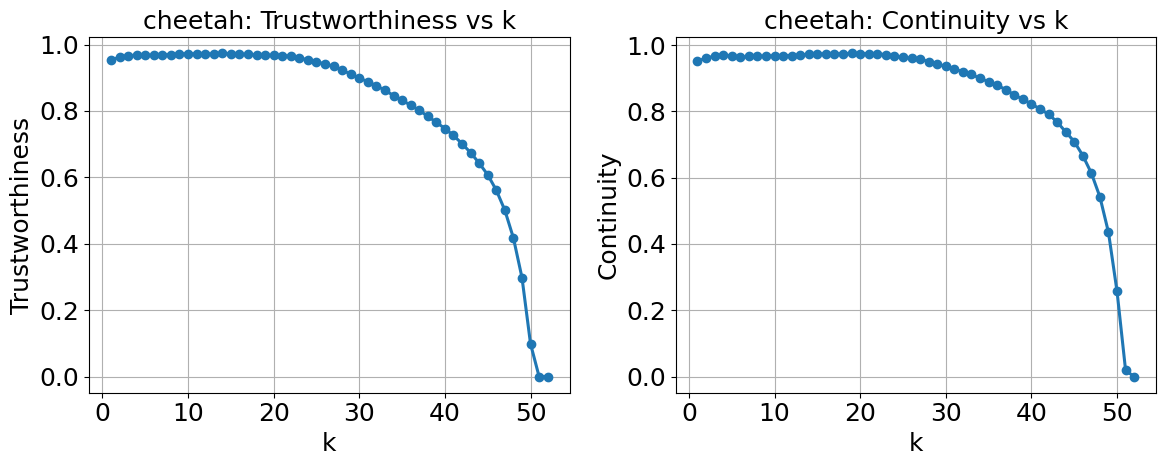


=== Evaluating Trustworthiness/Continuity for cheetah_mlp ===
  Seed 0...
(80, 2)
[[-0.11990582 -0.22973272  0.89655906]
 [ 0.28307122 -0.59135759 -0.72465783]
 [-0.12764694 -0.2182025   0.89410841]
 [ 0.20517862 -0.71642148 -0.6088745 ]
 [ 0.30975512 -0.68353659 -0.62408167]
 [ 0.08673617 -0.40697238  0.83131617]
 [ 0.28570783 -0.71615386 -0.59695756]
 [-0.01672388 -0.29401854  0.85363424]
 [ 0.26563355 -0.79724485 -0.47273204]
 [-0.47819462 -0.74260134 -0.26107177]
 [ 0.08595929 -0.38454315  0.82534218]
 [-0.20992723 -0.87113482 -0.17507565]
 [ 0.05544759 -0.34704626  0.83938599]
 [ 0.03693908 -0.29355305  0.81884092]
 [-0.33102158 -0.84144026 -0.06019046]
 [-0.41839218 -0.78346658 -0.13930452]
 [-0.33121753 -0.85925484 -0.04807805]
 [-0.35332644 -0.05784871  0.87376666]
 [ 0.38076892 -0.51734424  0.65906167]
 [-0.4094255  -0.85419863 -0.01928132]
 [ 0.02732147 -0.27559832  0.85413927]
 [ 0.06218911 -0.30539954  0.85638887]
 [-0.00268392 -0.22190973  0.88717484]
 [-0.55093753 -0.699

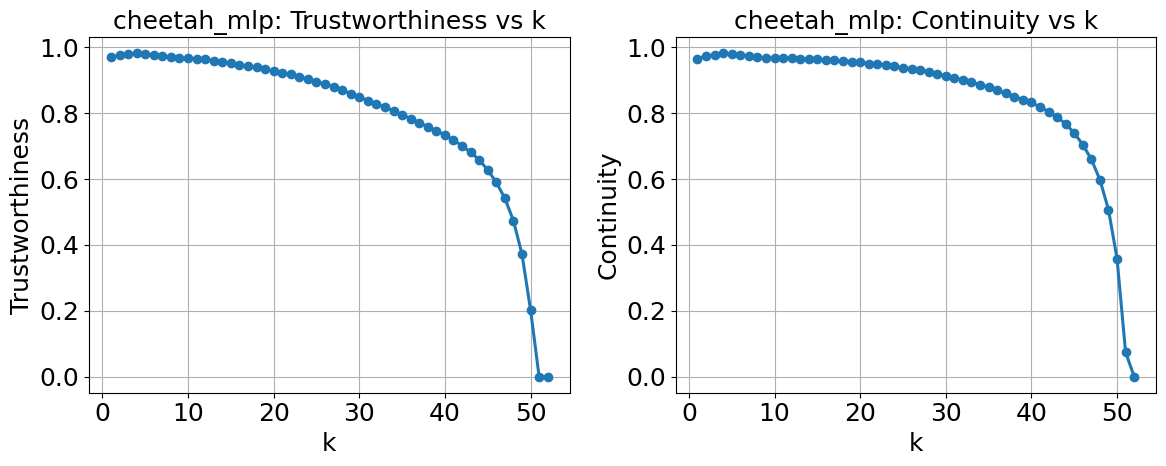


=== Evaluating Trustworthiness/Continuity for cheetah_db ===
  Seed 0...
(80, 2)
[[ 8.28023970e-01  1.56936616e-01 -3.89675826e-01]
 [ 9.52480584e-02 -9.21272755e-01  1.95447579e-01]
 [ 8.04880857e-01  3.45808208e-01 -2.95731843e-01]
 [-1.33176982e-01 -8.68608296e-01  3.94855529e-01]
 [-1.46800444e-01 -8.56296003e-01  3.95946741e-01]
 [ 8.33666444e-01  1.30015403e-01 -3.74716043e-01]
 [-1.85104802e-01 -8.21697712e-01  4.64771837e-01]
 [ 8.09880018e-01  1.58949733e-01 -4.25606489e-01]
 [-1.29198208e-01 -7.72676826e-01  5.38888335e-01]
 [ 1.85863689e-01 -6.12221003e-01  7.04003751e-01]
 [ 8.08367610e-01  1.39396250e-01 -4.27599669e-01]
 [-4.86327223e-02 -5.08319616e-01  7.89657056e-01]
 [ 7.73696542e-01  1.49442270e-01 -4.36694533e-01]
 [ 7.31066823e-01 -8.14181864e-02 -5.32742739e-01]
 [ 8.49860907e-03 -4.13622499e-01  8.14688504e-01]
 [ 9.45340246e-02 -5.25920928e-01  7.64615655e-01]
 [-4.92870584e-02 -3.39704216e-01  8.53897035e-01]
 [ 7.31443048e-01  2.67805636e-01 -4.77475703e-01]


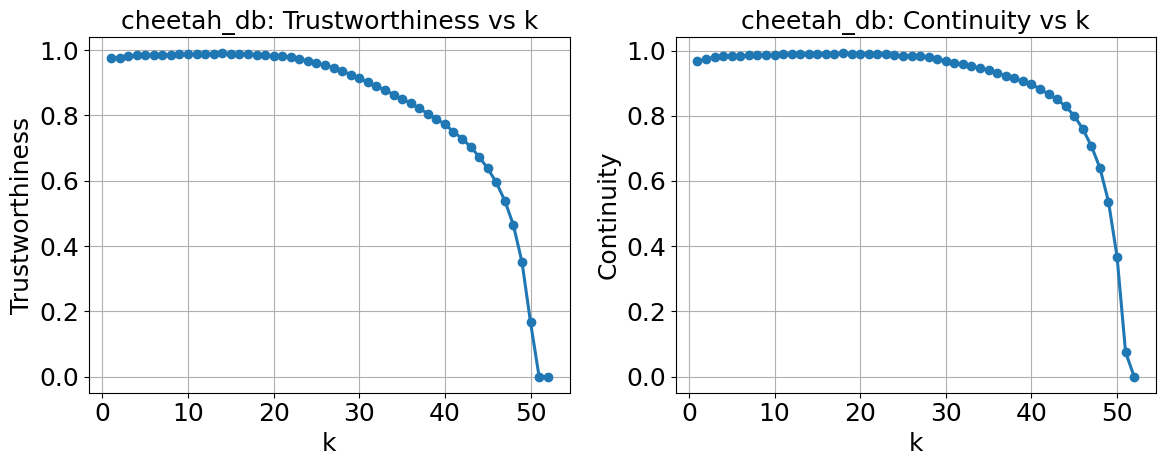

In [20]:
environments = {
    "cheetah": {
        "trajectory_dir": "../../trajectories/morld/mo-halfcheetah-v5/seed{seed}",
        "embedding_path": "../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_be_MHC_e100_seed{seed}.json"
    },
    "cheetah_mlp": {
        "trajectory_dir": "../../trajectories/morld/mo-halfcheetah-v5/seed{seed}",
        "embedding_path": "../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_mlp_MHC_e100_seed{seed}_mlp.json"
    },
    "cheetah_db": {
        "trajectory_dir": "../../trajectories/morld/mo-halfcheetah-v5/seed{seed}",
        "embedding_path": "../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_db_MHC_e100_seed{seed}_mlp.json"
    }
}

for env_name, cfg in environments.items():
    mean_trust, mean_cont = evaluate_tc_over_seeds(
        env_name,
        cfg,
        num_seeds=5,
        k_min=1,
        k_max=None   # or set a safe cap
    )
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams["text.usetex"] = False
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["mathtext.default"] = "regular"

    plt.close("all")
    plot_tc_curves(env_name, mean_trust, mean_cont)



=== Evaluating Trustworthiness/Continuity for cheetah ===
  Seed 0...
(80, 2)
[[ 0.8447786  -0.49572819 -0.20088181]
 [-0.84333628  0.460435    0.241805  ]
 [ 0.84614503 -0.4911381  -0.20623328]
 [-0.82584047  0.3253642   0.35374433]
 [-0.84418947  0.35564068  0.34002888]
 [ 0.84872901 -0.48159677 -0.21715425]
 [-0.84695619  0.35272071  0.3449263 ]
 [ 0.84704667 -0.48783481 -0.21001963]
 [-0.79603022  0.15441602  0.48938632]
 [-0.60266066 -0.09808402  0.57194436]
 [ 0.84934324 -0.47954896 -0.21954519]
 [-0.62332398 -0.17123373  0.65636325]
 [ 0.84925807 -0.47977969 -0.219263  ]
 [ 0.84908867 -0.47975913 -0.21914837]
 [-0.57916373 -0.23185572  0.67797005]
 [-0.53132391 -0.26367491  0.66984975]
 [-0.60420239 -0.21596351  0.68292886]
 [ 0.85014188 -0.47582412 -0.22364242]
 [ 0.85118073 -0.47099397 -0.22895794]
 [-0.55142522 -0.27031666  0.69189638]
 [ 0.85822797 -0.42951584 -0.27312225]
 [ 0.86055356 -0.40571225 -0.29710799]
 [ 0.86190951 -0.40770516 -0.29632631]
 [-0.45401791 -0.3615452

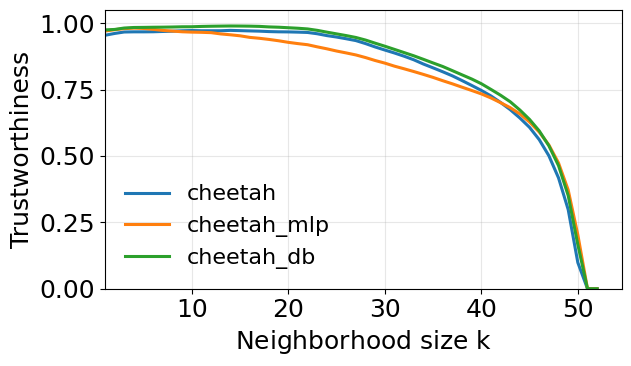

In [23]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["mathtext.default"] = "regular"

plt.close("all")
fig, ax = plt.subplots(figsize=(6.5, 4))

colors = {
    "cheetah": "tab:blue",
    "cheetah_mlp": "tab:orange",
    "cheetah_db": "tab:green",
}

for env_name, cfg in environments.items():
    mean_trust, _ = evaluate_tc_over_seeds(
        env_name,
        cfg,
        num_seeds=5,
        k_min=1,
        k_max=None
    )

    ks = sorted(mean_trust.keys())
    trust_vals = [mean_trust[k] for k in ks]

    ax.plot(
        ks,
        trust_vals,
        label=env_name,
        color=colors.get(env_name, None)
    )

ax.set_xlabel("Neighborhood size $k$")
ax.set_ylabel("Trustworthiness")
ax.set_ylim(0.0, 1.05)
ax.set_xlim(left=min(ks))
ax.grid(True, alpha=0.3)

ax.legend(frameon=False)
fig.tight_layout()
plt.show()



=== Evaluating Trustworthiness/Continuity for cheetah ===
  Seed 0...
(80, 2)
[[ 0.8447786  -0.49572819 -0.20088181]
 [-0.84333628  0.460435    0.241805  ]
 [ 0.84614503 -0.4911381  -0.20623328]
 [-0.82584047  0.3253642   0.35374433]
 [-0.84418947  0.35564068  0.34002888]
 [ 0.84872901 -0.48159677 -0.21715425]
 [-0.84695619  0.35272071  0.3449263 ]
 [ 0.84704667 -0.48783481 -0.21001963]
 [-0.79603022  0.15441602  0.48938632]
 [-0.60266066 -0.09808402  0.57194436]
 [ 0.84934324 -0.47954896 -0.21954519]
 [-0.62332398 -0.17123373  0.65636325]
 [ 0.84925807 -0.47977969 -0.219263  ]
 [ 0.84908867 -0.47975913 -0.21914837]
 [-0.57916373 -0.23185572  0.67797005]
 [-0.53132391 -0.26367491  0.66984975]
 [-0.60420239 -0.21596351  0.68292886]
 [ 0.85014188 -0.47582412 -0.22364242]
 [ 0.85118073 -0.47099397 -0.22895794]
 [-0.55142522 -0.27031666  0.69189638]
 [ 0.85822797 -0.42951584 -0.27312225]
 [ 0.86055356 -0.40571225 -0.29710799]
 [ 0.86190951 -0.40770516 -0.29632631]
 [-0.45401791 -0.3615452

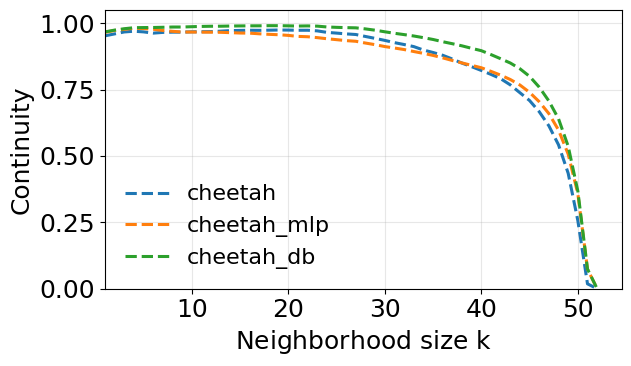

In [24]:
plt.close("all")
fig, ax = plt.subplots(figsize=(6.5, 4))

for env_name, cfg in environments.items():
    _, mean_cont = evaluate_tc_over_seeds(
        env_name,
        cfg,
        num_seeds=5,
        k_min=1,
        k_max=None
    )

    ks = sorted(mean_cont.keys())
    cont_vals = [mean_cont[k] for k in ks]

    ax.plot(
        ks,
        cont_vals,
        label=env_name,
        color=colors.get(env_name, None),
        linestyle="--"
    )

ax.set_xlabel("Neighborhood size $k$")
ax.set_ylabel("Continuity")
ax.set_ylim(0.0, 1.05)
ax.set_xlim(left=min(ks))
ax.grid(True, alpha=0.3)

ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Scatterplots


In [5]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants_3d

lipschitz_constants_highway, d_objs_highway, d_embs_highway, sorted_pf_highway, sorted_emb_highway = (
    compute_lipschitz_constants_3d(pareto_frontier=returns_highway, embeddings=all_t_emb_high)
)
lipschitz_constants_cheetah, d_objs_cheetah, d_embs_cheetah, sorted_pf_cheetah, sorted_emb_cheetah = (
    compute_lipschitz_constants(pareto_frontier=returns_cheetah, embeddings=all_t_emb_cheetah)
)


lipschitz_constants_hopper_2d, d_objs_hopper_2d, d_embs_hopper_2d, sorted_pf_hopper_2d, sorted_emb_hopper_2d = (
    compute_lipschitz_constants(pareto_frontier=returns_hopper_2d, embeddings=all_t_emb_hopper_2d)
)
lipschitz_constants_hopper_3d, d_objs_hopper_3d, d_embs_hopper_3d, sorted_pf_hopper_3d, sorted_emb_hopper_3d = (
    compute_lipschitz_constants_3d(pareto_frontier=returns_hopper_3d, embeddings=all_t_emb_hopper_3d)
)


Computing Lipschitz constant between policy 0 and 1
2.825950643170885
0.0547583819688177
Lipshitz: 0.019376977478762873
Lipschitz constant for policy 0 ([ 310.74908793 -108.12961902], [-0.10328497 -0.53112257  0.71782571]) to 1 ([ 309.29723363 -105.70513637], [-0.14565514 -0.49979538  0.73272055]): 0.019376977478762873, d_obj: 2.825950643170885, d_emb: 0.0547583819688177
Computing Lipschitz constant between policy 1 and 2
2.7746412039307944
0.04947182059274474
Lipshitz: 0.017829988440544575
Lipschitz constant for policy 1 ([ 309.29723363 -105.70513637], [-0.14565514 -0.49979538  0.73272055]) to 2 ([ 306.52434554 -105.60651863], [-0.10682419 -0.52140772  0.71098292]): 0.017829988440544575, d_obj: 2.7746412039307944, d_emb: 0.04947182059274474
Computing Lipschitz constant between policy 2 and 3
1.2389537465973897
0.07044322752232716
Lipshitz: 0.05685702772665201
Lipschitz constant for policy 2 ([ 306.52434554 -105.60651863], [-0.10682419 -0.52140772  0.71098292]) to 3 ([ 306.23030094 -10

/Users/florian/Documents/Behavior-vs-Objective-Space/morl_behavior_objective/analysis/utils_analysis.py:107: RuntimeWarning: invalid value encountered in scalar divide
  lipschitz_constants.append(d_emb / d_obj)


# Mean Scatterplots

In [6]:
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants_3d
emb_dst_cheetah = []
emb_dst_hopper_3d = []
for seed in range(5):
    # Configuration for datasets
    environments = {
        "cheetah": {
            "trajectory_dir": "../../trajectories/morld/mo-halfcheetah-v5/seed0",
            "embedding_path": f"../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_be_MHC_e100_seed{seed}.json",
            "mlp_path": f"../../trajectories/morld/mo-halfcheetah-v5/embeddings/mean_mlp_MHC_e100_seed{seed}_mlp.json",
        },
        "hopper_3d": {
            "trajectory_dir": f"../../trajectories/morld/mo-hopper-v5/seed0",
            "embedding_path": f"../../trajectories/morld/mo-hopper-v5/embeddings/mean_be_MHo_e100_seed{seed}.json",
        },
    }
    all_t_emb_cheetah, _=load_transformer_embeddings(environments["cheetah"]["embedding_path"])
    all_t_emb_hopper_3d, _=load_transformer_embeddings(environments["hopper_3d"]["embedding_path"])

    lipschitz_constants_hopper_3d, d_objs_hopper_3d, d_embs_hopper_3d, sorted_pf_hopper_3d, sorted_emb_hopper_3d = (
    compute_lipschitz_constants_3d(pareto_frontier=returns_hopper_3d, embeddings=all_t_emb_hopper_3d)    
)
   
    lipschitz_constants_cheetah, d_objs_cheetah, d_embs_cheetah, sorted_pf_cheetah, sorted_emb_cheetah = (
    compute_lipschitz_constants(pareto_frontier=returns_cheetah, embeddings=all_t_emb_cheetah)
)   

    emb_dst_cheetah.append(d_embs_cheetah)
    emb_dst_hopper_3d.append(d_embs_hopper_3d)

emb_dst_cheetah=np.array(emb_dst_cheetah)
emb_dst_hopper_3d=np.array(emb_dst_hopper_3d)

#compute mean of seeds for emb_dst_cheetah and emb_dst_hopper_3d
emb_dst_cheetah_mean=np.mean(emb_dst_cheetah,axis=0)
emb_dst_hopper_3d_mean=np.mean(emb_dst_hopper_3d,axis=0)
print(emb_dst_cheetah_mean.shape)
print(emb_dst_hopper_3d_mean.shape)

Computing Lipschitz constant between policy 0 and 1
2.825950643170885
0.019530643358346037
Lipshitz: 0.006911176387861994
Lipschitz constant for policy 0 ([ 310.74908793 -108.12961902], [ 0.23084506 -0.75650603  0.52699244]) to 1 ([ 309.29723363 -105.70513637], [ 0.21602078 -0.75753558  0.5396663 ]): 0.006911176387861994, d_obj: 2.825950643170885, d_emb: 0.019530643358346037
Computing Lipschitz constant between policy 1 and 2
2.7746412039307944
0.08559949763513035
Lipshitz: 0.03085065467703095
Lipschitz constant for policy 1 ([ 309.29723363 -105.70513637], [ 0.21602078 -0.75753558  0.5396663 ]) to 2 ([ 306.52434554 -105.60651863], [ 0.28479844 -0.76131493  0.48884678]): 0.03085065467703095, d_obj: 2.7746412039307944, d_emb: 0.08559949763513035
Computing Lipschitz constant between policy 2 and 3
1.2389537465973897
0.02092590984171632
Lipshitz: 0.01688998471426908
Lipschitz constant for policy 2 ([ 306.52434554 -105.60651863], [ 0.28479844 -0.76131493  0.48884678]) to 3 ([ 306.23030094 -

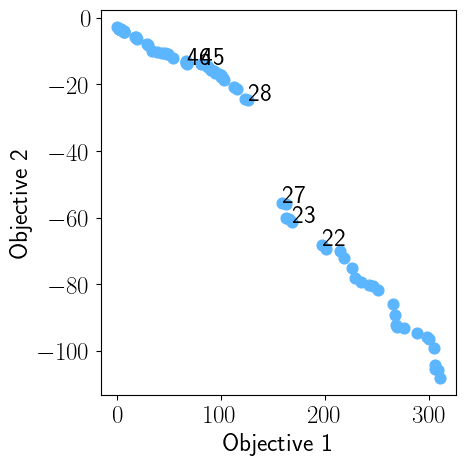

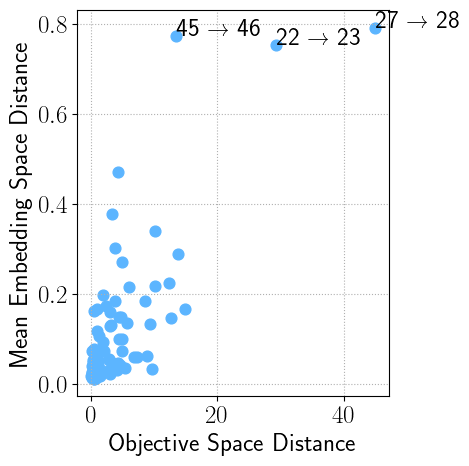

In [13]:
plt.figure(figsize=(5, 5))

plt.scatter(
    sorted_pf_cheetah[:, 0],
    sorted_pf_cheetah[:, 1],
    c=colors[0],
    s=60
)

plt.xlabel("Objective 1")
plt.ylabel("Objective 2")


for i in range(len(sorted_pf_cheetah)):
    if i in {45, 46, 27, 28, 22, 23}:
        plt.annotate(
            str(i),
            (sorted_pf_cheetah[i, 0], sorted_pf_cheetah[i, 1])
        )

plt.tight_layout()
plt.savefig(
    f"cheetah_pf.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()



plt.figure(figsize=(5, 5))

plt.scatter(
    d_objs_cheetah,
    emb_dst_cheetah_mean,
    c=colors[0],
    s=60
)

plt.xlabel("Objective Space Distance")
plt.ylabel("Mean Embedding Space Distance")

plt.grid(True, linestyle=":")

for i in range(len(d_objs_cheetah)):
    if i in {45, 27, 22}:
        plt.annotate(
            f"{i} → {i + 1}",
            (d_objs_cheetah[i], emb_dst_cheetah_mean[i])
        )

plt.tight_layout()
plt.savefig(
    f"cheetah_d_mean.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()


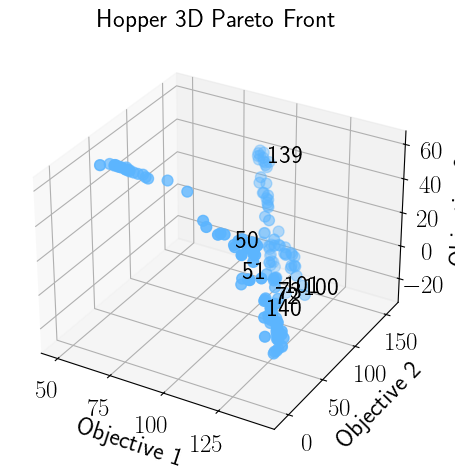

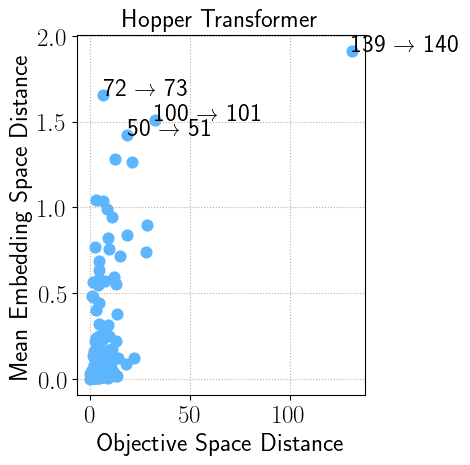

In [14]:
# Hopper
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")



ax.scatter(
    sorted_pf_hopper_3d[:, 0],
    sorted_pf_hopper_3d[:, 1],
    sorted_pf_hopper_3d[:, 2],
    c=colors[0],
    s=60
)

ax.set_xlabel("Objective 1", labelpad=6)
ax.set_ylabel("Objective 2", labelpad=6)
ax.set_zlabel("Objective 3", labelpad=6)

ax.set_title("Hopper 3D Pareto Front", pad=10)

for i in range(len(sorted_pf_hopper_3d)):
    if i in {72, 73, 100, 101, 50, 51, 139, 140}:
        ax.text(
            sorted_pf_hopper_3d[i, 0],
            sorted_pf_hopper_3d[i, 1],
            sorted_pf_hopper_3d[i, 2],
            str(i),

            color="k"
        )

plt.tight_layout()
plt.savefig(
    f"hopper_3d_pf.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(5, 5))

plt.scatter(
    d_objs_hopper_3d,
    emb_dst_hopper_3d_mean,
    c=colors[0],
    s=60
)

plt.xlabel("Objective Space Distance")
plt.ylabel("Mean Embedding Space Distance")
plt.title("Hopper Transformer")

plt.grid(True, linestyle=":")

for i in range(len(d_objs_hopper_3d)):
    if i in {72, 100, 50, 139}:
        plt.annotate(
            f"{i} → {i + 1}",
            (d_objs_hopper_3d[i], emb_dst_hopper_3d_mean[i])
        )

plt.tight_layout()
plt.savefig(
    f"hopper_3d_mean.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()



### Cheetah

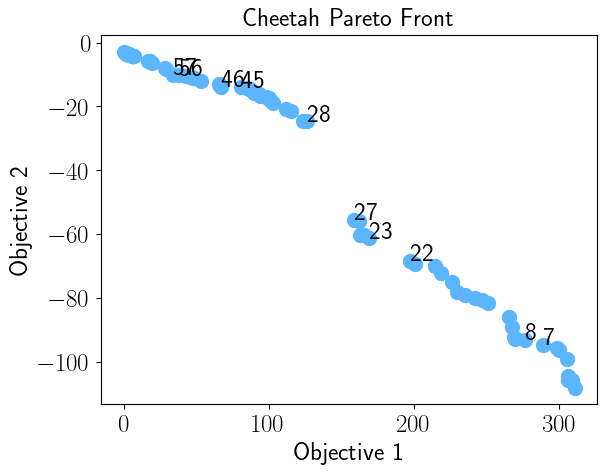

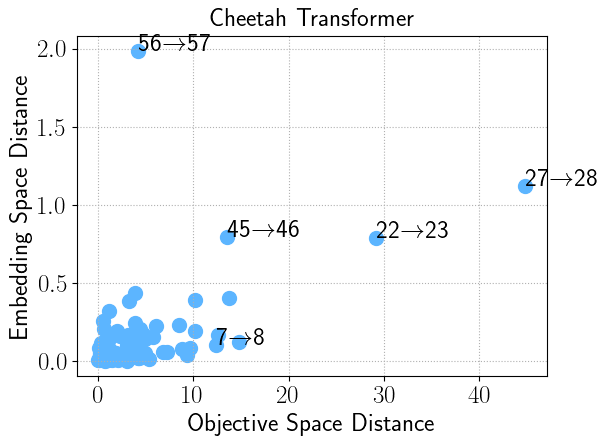

In [49]:
plt.scatter(sorted_pf_cheetah[:, 0], sorted_pf_cheetah[:, 1], c=colors[0], s=100)
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
for i, txt in enumerate(range(len(sorted_pf_cheetah))):
    if i in {45, 46 , 7, 8, 27, 28, 22, 23, 56, 57}:
        plt.annotate(f"{i}", (sorted_pf_cheetah[i, 0], sorted_pf_cheetah[i, 1]))
plt.title("Cheetah Pareto Front")
plt.savefig(f"pareto_fronts/cheetah_{seed}.pdf")
plt.show()

# # plot cheetah embeddings in 3d
# fig = plt.figure()
# ax = fig.add_subplot(111, projection="3d")
# ax.scatter(sorted_emb_cheetah[:, 0], sorted_emb_cheetah[:, 1], sorted_emb_cheetah[:, 2], c=colors[0], s=100)
# for i, txt in enumerate(range(len(sorted_emb_cheetah))):
#     ax.text(sorted_emb_cheetah[i, 0], sorted_emb_cheetah[i, 1], sorted_emb_cheetah[i, 2], f"{i}", fontsize=16, color="k")
# ax.set_xlabel("Embedding Dim 1")
# ax.set_ylabel("Embedding Dim 2")
# ax.set_zlabel("Embedding Dim 3")
# plt.title("Cheetah Embeddings")
# plt.tight_layout()
# plt.show()

# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
plt.scatter(d_objs_cheetah, d_embs_cheetah, c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Cheetah Transformer")

# add index as text labels
for i, txt in enumerate(range(len(d_objs_cheetah))):
    if i in {45, 7, 27, 22, 56}:
        plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_cheetah[i], d_embs_cheetah[i]))

plt.grid(True, linestyle=":")
plt.tight_layout()
plt.savefig(f"scatterplots/cheetah_{seed}.pdf")
plt.show()

## Cheetah analysis

In [ ]:
# get policies with the highest lipshitz jump
sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
print(highest_pairs)
org_policy_id = np.lexsort(returns_cheetah.T)[highest_pairs[-1]]
render_policy(
    env_id="mo-halfcheetah-v5",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/half-cheetah/highest",
    base_path="../..",
)
render_policy(
    env_id="mo-halfcheetah-v5",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/half-cheetah/highest",
    base_path="../..",
)

In [ ]:
# Get policies with the  secondhighest Lipschitz constants
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
highest_pairs[-1]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_cheetah.T)[highest_pairs[-2]]
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/half-cheetah/second_highest",
    base_path="../..",
)
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/half-cheetah/second_highest",
    base_path="../..",
)

In [ ]:
# lowest
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[:]]
highest_pairs[0]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_cheetah.T)[highest_pairs[0]]
print(highest_pairs)
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/half-cheetah/lowest",
    base_path="../..",
)
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/half-cheetah/lowest",
    base_path="../..",
)

In [ ]:
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[:]]
highest_pairs[0]

## Analysis Hopper 2D


## Analysis Hopper 3D


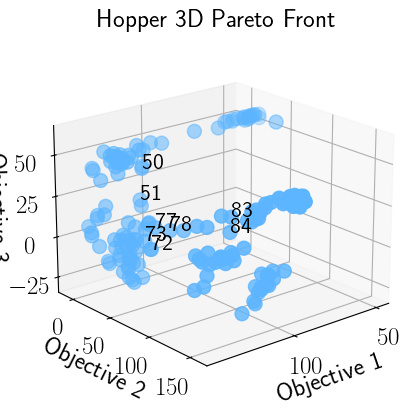

In [59]:
# Hopper 3D Pareto Front 3D  scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=20, azim=50)
ax.scatter(sorted_pf_hopper_3d[:, 0], sorted_pf_hopper_3d[:, 1], sorted_pf_hopper_3d[:, 2], c=colors[0], s=100)
ax.set_xlabel("Objective 1")
ax.set_ylabel("Objective 2")
ax.set_zlabel("Objective 3")
plt.title("Hopper 3D Pareto Front")
for i, txt in enumerate(range(len(sorted_pf_hopper_3d))):
    if i in {77,78,72,73,50,51,83,84}:
        ax.text(sorted_pf_hopper_3d[i, 0], sorted_pf_hopper_3d[i, 1], sorted_pf_hopper_3d[i, 2], f"{i}", fontsize=16, color="k")
plt.savefig(f"pareto_fronts/hopper_3d_0.pdf")
plt.show()

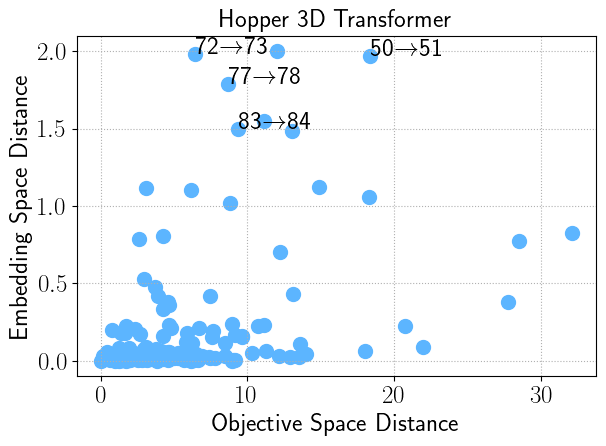

In [51]:
# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
# removes point 139->140 because it is a jump due to 3d ordring
plt.scatter(np.concatenate([d_objs_hopper_3d[:139], d_objs_hopper_3d[140:]]), np.concatenate([d_embs_hopper_3d[:139], d_embs_hopper_3d[140:]]), c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Hopper 3D Transformer")

# add index as text labels
for i, txt in enumerate(range(len(d_objs_hopper_3d))):
    if i in {77,72,50,83}:
        plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_hopper_3d[i], d_embs_hopper_3d[i]))

plt.grid(True, linestyle=":")
plt.tight_layout()
plt.savefig(f"scatterplots/hopper_3d_{seed}.pdf")
plt.show()

## Highway analysis

In [ ]:
# Get policies with the highest Lipschitz constants

sorted_idx = np.argsort(lipschitz_constants_highway)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
highest_pairs[-1]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_highway.T)[highest_pairs[-1]]
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/highway/highest",
    base_path="../..",
)
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/highway/highest",
    base_path="../..",
)

In [ ]:
# Get policies with the highest Lipschitz constants

sorted_idx = np.argsort(lipschitz_constants_highway)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
highest_pairs[-1]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_highway.T)[highest_pairs[-2]]
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/highway/second_highest",
    base_path="../..",
)
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/highway/second_highest",
    base_path="../..",
)

(40,)
(40,)


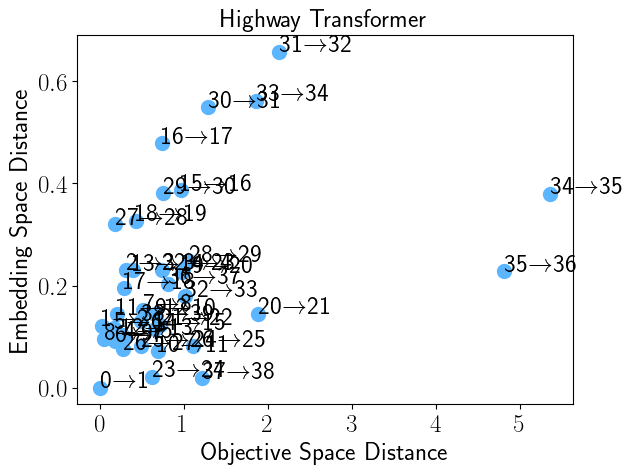

In [4]:
# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
print(d_objs_highway.shape)
print(d_embs_highway.shape)
plt.scatter(d_objs_highway[:39], d_embs_highway[:39], c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Highway Transformer")
# add index as text labels
for i, txt in enumerate(range(len(d_objs_highway))):
    # if i in {0, 31, 20, 3, 34, 31, 32}:
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_highway[i], d_embs_highway[i]))

plt.show()

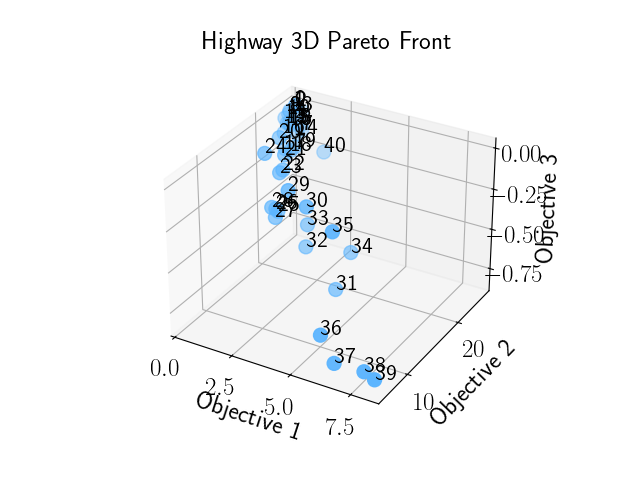

In [7]:
# Highway Pareto Front 3D  scatter plot
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_pf_highway[:, 0], sorted_pf_highway[:, 1], sorted_pf_highway[:, 2], c=colors[0], s=100)
ax.set_xlabel("Objective 1")
ax.set_ylabel("Objective 2")
ax.set_zlabel("Objective 3")
plt.title("Highway 3D Pareto Front")
for i, txt in enumerate(range(len(sorted_pf_highway))):
    # if i in {0, 1, 31, 32, 33, 20, 21, 3, 4, 34}:
    ax.text(sorted_pf_highway[i, 0], sorted_pf_highway[i, 1], sorted_pf_highway[i, 2], f"{i}", fontsize=16, color="k")
plt.show()

## Render policies


### Cheetah

In [11]:
#Cheetah is a two-objective problem, so we use normal lextargsort
# Get policies with the  secondhighest Lipschitz constants
import numpy as np

policies_list=[[45,46], [22,23], [56,57]]
for policies in policies_list:
    # see what policies these correspond to in the original pareto front
    org_policy_id = np.lexsort(returns_cheetah.T)[policies]
    print(sorted_pf_cheetah[policies]==returns_cheetah[org_policy_id])


[[ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]]


In [16]:
a=[1,2,3]
a[3]=1

IndexError: list assignment index out of range

In [14]:
pareto_frontier=returns_highway
pf_points = pareto_frontier.copy()
n_points = len(pf_points)

lowest_obj_idx = np.argmin(pf_points[:, 0])
seq_idx = [lowest_obj_idx]  # start with point with lowest obj value in first dimension
remaining_idx = list(range(1, n_points))

while remaining_idx:
    last = pf_points[seq_idx[-1]]
    remaining = pf_points[remaining_idx]
    distances = np.linalg.norm(remaining - last, axis=1)
    nearest_idx = remaining_idx[np.argmin(distances)]
    seq_idx.append(nearest_idx)
    remaining_idx.remove(nearest_idx)

org_policy_id = np.array(seq_idx)[[2,3]]
sorted_pf_highway[ [2,3]]==returns_highway[org_policy_id]

array([[ True,  True,  True],
       [ True,  True,  True]])